In [1]:
from Forecast.SimpleTransformerForecast import SimpleTransformerForecast
from Forecast.PatchTransformerForecast import PatchTransformerForecast
from Dataloaders.DataloaderECG import ECGDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Function to train the model
def train_loop(model, train, val, optimizer, scheduler=None, patience=5, epochs=100, lossf=F.mse_loss):
    """_Training loop for the model_

    Args:
        model: model to train
        optimizer: pytorch optimizer, for example torch.optim.Adam
        train: training data
        val: validation data
        epochs: number of epochs

    Returns:
        _type_: training history, a dictionary with the training and validation loss for each epoch
    """
    def epoch_loss(dataset):
        data_loss = 0.0
        for i, (lookback_data, horizon_data) in enumerate(dataset):
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')
            outputs = model(inputs).squeeze()
            loss = lossf(y, outputs)
            data_loss += loss.item()  
        return data_loss / (i + 1)
    
    def early_stopping(val_loss, patience=5):
        if len(val_loss) > patience:
            if val_loss[-1] > np.mean(val_loss[-(patience+1):-1]):
                return True
    
    hist_loss = {'train': [], 'val': []}
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # loop for all the epochs
        for i, (lookback_data, horizon_data) in enumerate(train):
            # take the data and upload it to the GPU
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')

            # Reset the gradients
            optimizer.zero_grad()

            # Apply the data to the model
            outputs = model(inputs).squeeze()
            # Calculate the loss
            loss = lossf(y, outputs)

            # Make the backward pass
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Calculate the loss in the training and validation sets
        with torch.no_grad():
            hist_loss['train'].append(epoch_loss(train))
            hist_loss['val'].append(epoch_loss(val))

        # Show the loss in the training and validation sets
        pbar.set_postfix({'train': hist_loss['train'][-1], 'val': hist_loss['val'][-1], 'lr': optimizer.param_groups[0]['lr']})

        # If the loss in the validation set does not decrease, stop the training
        if early_stopping(hist_loss['val'], patience):
            break
            
    return hist_loss 

In [58]:
lookback = 100
horizon = 25
batch_size = 2048
stride = 10

In [59]:
train = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='train',
                   nsamples=2500,
                   channel=0,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
val = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='validation',
                   nsamples=200,
                   channel=0,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
train = DataLoader(train, batch_size=batch_size, shuffle=True)
val = DataLoader(val, batch_size=batch_size, shuffle=False)


Loading data from ../Preprocess/PTBXL
train
X_train shape is (220000, 8, 100)
y_train shape is (220000, 25)
NORM=None
Loading data from ../Preprocess/PTBXL
validation
X_train shape is (17600, 8, 100)
y_train shape is (17600, 25)
NORM=None


In [60]:
# model = SimpleTransformerForecast(lookback=lookback,
#                                   horizon=horizon,
#                                   input_dim=8,
#                                   target_dim=1,
#                                   d_model=16,
#                                   n_heads=2,
#                                   num_layers=6, dropout=0).to('cuda')
# model.compile()

In [61]:
model = PatchTransformerForecast(lookback=lookback,
                                horizon=horizon,
                                input_dim=8,
                                target_dim=1,
                                d_model=32,
                                n_heads=4,
                                num_layers=2, dropout=0, patch_len=10).to('cuda')

In [62]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=10, gamma=0.90)

In [63]:
# # Testing the model with random input
# random_input = torch.randn(32, 8, 120).to('cuda')
# model.to('cuda')
# model(random_input).shape

In [64]:
hist_loss = train_loop(model, train, val, optimizer, scheduler, epochs=1000, patience=250)

  0%|          | 0/1000 [00:00<?, ?it/s]

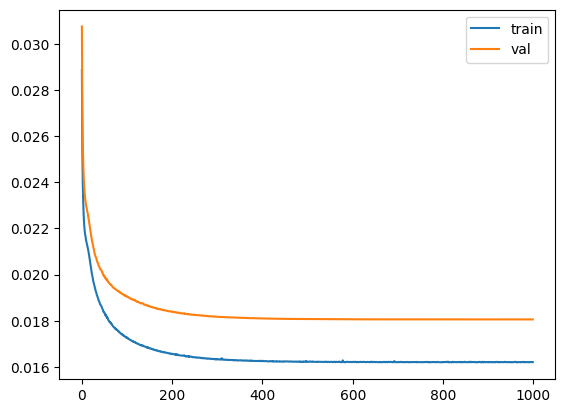

In [65]:
plt.plot(hist_loss['train'], label='train')
plt.plot(hist_loss['val'], label='val')
plt.legend()


In [66]:
print(scheduler.get_last_lr())

[2.6561398887587547e-09]


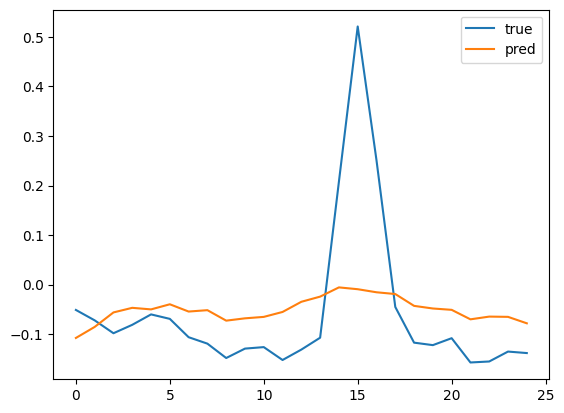

In [67]:
X, y = train.dataset[0]


pred = model(torch.tensor(X).unsqueeze(0).to('cuda')).squeeze().cpu().detach().numpy()
plt.plot(y, label='true')
plt.plot(pred, label='pred')
plt.legend()

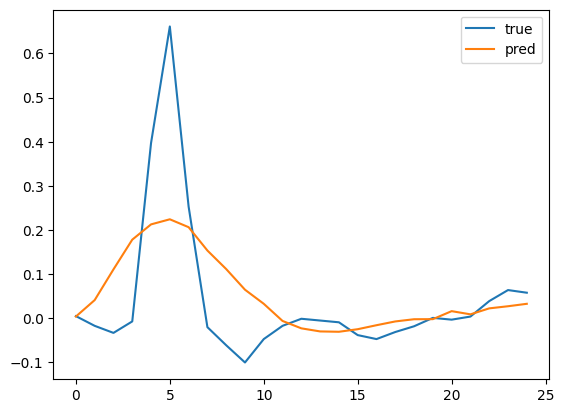

In [68]:
X, y = val.dataset[25]


pred = model(torch.tensor(X).unsqueeze(0).to('cuda')).squeeze().cpu().detach().numpy()
plt.plot(y, label='true')
plt.plot(pred, label='pred')
plt.legend()

In [69]:
def dataset_loss(dataset):
    data_loss = 0.0
    for i, (lookback_data, horizon_data) in enumerate(dataset):
        inputs = lookback_data.to('cuda')
        y = horizon_data.to('cuda')
        outputs = model(inputs).squeeze()
        loss = F.mse_loss(y, outputs)
        data_loss += loss.item()
    return data_loss / (i + 1)
print('Train loss:', dataset_loss(train))
print('Val loss:', dataset_loss(val))

Train loss: 0.01619872975991004
Val loss: 0.01805597088403172
